# Procesamiento distribuido

1. Conteos distribuidos

    - Ratings por película y por usuario usando RDD y DataFrame


2. Top 20 películas más calificadas

    - Ranking con títulos (join con movies_clean)
    - Gráfica de barras ordenada por popularidad

3. Benchmark RDD vs DataFrame

    - Correr el mismo conteo con ambas APIs midiendo tiempo
    - Graficar la diferencia
    - Explicar por qué uno es más rápido

In [2]:
from pathlib import Path
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, desc
import time

spark = SparkSession.builder \
    .appName("Fase2-Procesamiento-Distribuido") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

BASE    = Path("..") 
OUTPUT  = BASE / "outputs" / "results"
FIGURES = BASE / "outputs" / "figures"

# cargamos los Parquet limpios
ratings = spark.read.parquet(str(OUTPUT / "ratings_clean.parquet"))
movies  = spark.read.parquet(str(OUTPUT / "movies_clean.parquet"))

print(f"Spark {spark.version} listo")

Spark 4.1.1 listo


# Conteo con DataFrame

In [3]:
# DataFrame API
inicio = time.time()

conteo_df = (ratings
    .groupBy("movieId")
    .agg(count("*").alias("num_ratings"))
    .orderBy(desc("num_ratings"))
)
conteo_df.cache()
conteo_df.count()  # forzar ejecución para medir tiempo real

tiempo_df = time.time() - inicio
print(f"DataFrame: {tiempo_df:.2f} segundos")

DataFrame: 2.64 segundos


In [4]:
print(f"Particiones en ratings: {ratings.rdd.getNumPartitions()}")

Particiones en ratings: 10


# Conteo con RDD

In [5]:
# RDD API
inicio = time.time()

conteo_rdd = (ratings.rdd
    .map(lambda row: (row.movieId, 1))        # cada fila → (movieId, 1)
    .reduceByKey(lambda a, b: a + b)          # sumar por movieId
    .sortBy(lambda x: x[1], ascending=False) # ordenar por conteo
)
conteo_rdd.cache()
conteo_rdd.count()  # forzar ejecución

tiempo_rdd = time.time() - inicio
print(f"RDD:       {tiempo_rdd:.2f} segundos")
print(f"DataFrame: {tiempo_df:.2f} segundos")
print(f"DataFrame fue {tiempo_rdd/tiempo_df:.1f}x más rápido")

RDD:       8.84 segundos
DataFrame: 2.64 segundos
DataFrame fue 3.3x más rápido


# Top 20

In [ ]:
# top 20 películas más calificadas
top20 = (conteo_df
    .join(movies.select("movieId", "title"), on="movieId")
    .orderBy(desc("num_ratings"))
    .limit(20)
    .toPandas()
)

top20

,movieId,num_ratings,title
0,296,67310,Pulp Fiction (1994)
1,356,66172,Forrest Gump (1994)
2,318,63366,"Shawshank Redemption, The (1994)"
3,593,63299,"Silence of the Lambs, The (1991)"
4,480,59715,Jurassic Park (1993)
5,260,54502,Star Wars: Episode IV - A New Hope (1977)
6,110,53769,Braveheart (1995)
7,589,52244,Terminator 2: Judgment Day (1991)
8,2571,51334,"Matrix, The (1999)"
9,527,50054,Schindler's List (1993)


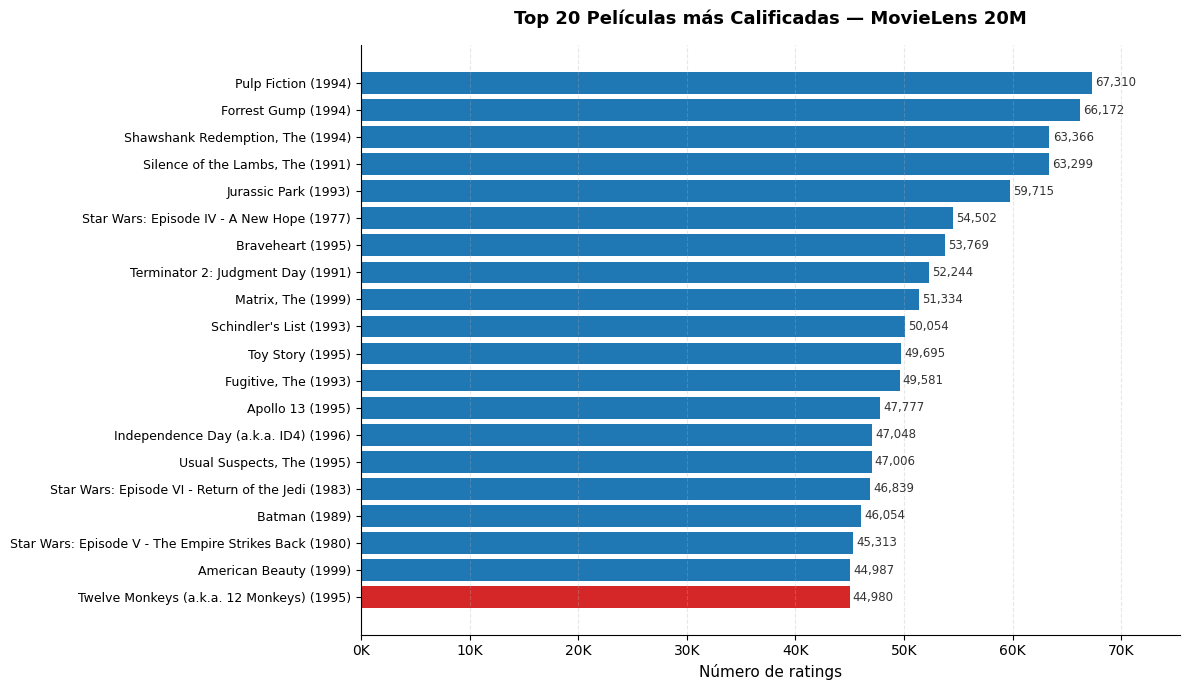

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(12, 7))

colores = ["#1f77b4" if i > 0 else "#d62728" for i in range(len(top20))]

bars = ax.barh(top20["title"], top20["num_ratings"], color=colores[::-1], edgecolor="none")
ax.invert_yaxis()

# etiquetas al final de cada barra
for bar, val in zip(bars, top20["num_ratings"]):
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=8.5, color="#333333")

ax.set_xlabel("Número de ratings", fontsize=11)
ax.set_title("Top 20 Películas más Calificadas — MovieLens 20M", fontsize=13, fontweight="bold", pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.set_xlim(0, top20["num_ratings"].max() * 1.12)
ax.tick_params(axis="y", labelsize=9)
ax.grid(axis="x", alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(f"{FIGURES}/08_top20_peliculas.png", bbox_inches="tight", dpi=150)
plt.show()

# Operaciones


Medimos el tiempo de 3 operaciones usando DataFrame y RDD:

1. **Conteo por película** — cuántos ratings tiene cada película
2. **Top 20 con join** — ranking con títulos (join entre ratings y movies)
3. **Conteo por usuario** — cuántos ratings tiene cada usuario

Para cada operación: arrancamos cronómetro → ejecutamos → guardamos tiempo.

Al final comparamos los 6 tiempos en una tabla.

- **Operación 1:** groupBy + count + orderBy
- **Operación 2:** groupBy + count + join + orderBy + limit
- **Operación 3:** groupBy + count + orderBy (mismo que Op1 pero por usuario)

In [8]:
resultados = []

# --- Operación 1: conteo por película ---
inicio = time.time()
ratings.groupBy("movieId").agg(count("*").alias("n")).orderBy(desc("n")).cache().count()
resultados.append(("Conteo por película", "DataFrame", time.time() - inicio))

inicio = time.time()
(ratings.rdd
    .map(lambda r: (r.movieId, 1))
    .reduceByKey(lambda a, b: a + b)
    .sortBy(lambda x: x[1], ascending=False)
    .count())
resultados.append(("Conteo por película", "RDD", time.time() - inicio))



# --- Operación 2: top 20 con join ---
inicio = time.time()
(ratings.groupBy("movieId").agg(count("*").alias("n"))
    .join(movies.select("movieId", "title"), on="movieId")
    .orderBy(desc("n")).limit(20).toPandas())
resultados.append(("Top 20 con join", "DataFrame", time.time() - inicio))

inicio = time.time()
movies_rdd = movies.rdd.map(lambda r: (r.movieId, r.title))
(ratings.rdd
    .map(lambda r: (r.movieId, 1))
    .reduceByKey(lambda a, b: a + b)
    .join(movies_rdd)
    .map(lambda x: (x[1][1], x[1][0]))
    .sortBy(lambda x: x[1], ascending=False)
    .take(20))
resultados.append(("Top 20 con join", "RDD", time.time() - inicio))



# --- Operación 3: conteo por usuario ---
inicio = time.time()
ratings.groupBy("userId").agg(count("*").alias("n")).orderBy(desc("n")).cache().count()
resultados.append(("Conteo por usuario", "DataFrame", time.time() - inicio))

inicio = time.time()
(ratings.rdd
    .map(lambda r: (r.userId, 1))
    .reduceByKey(lambda a, b: a + b)
    .sortBy(lambda x: x[1], ascending=False)
    .count())
resultados.append(("Conteo por usuario", "RDD", time.time() - inicio))



# mostrar resultados
import pandas as pd
df_bench = pd.DataFrame(resultados, columns=["Operación", "API", "Tiempo (s)"])
df_bench["Tiempo (s)"] = df_bench["Tiempo (s)"].round(2)
print(df_bench)

26/04/29 23:25:18 WARN CacheManager: Asked to cache already cached data.


             Operación        API  Tiempo (s)
0  Conteo por película  DataFrame        0.07
1  Conteo por película        RDD        8.32
2      Top 20 con join  DataFrame        0.95
3      Top 20 con join        RDD        9.20
4   Conteo por usuario  DataFrame        0.62
5   Conteo por usuario        RDD        8.75


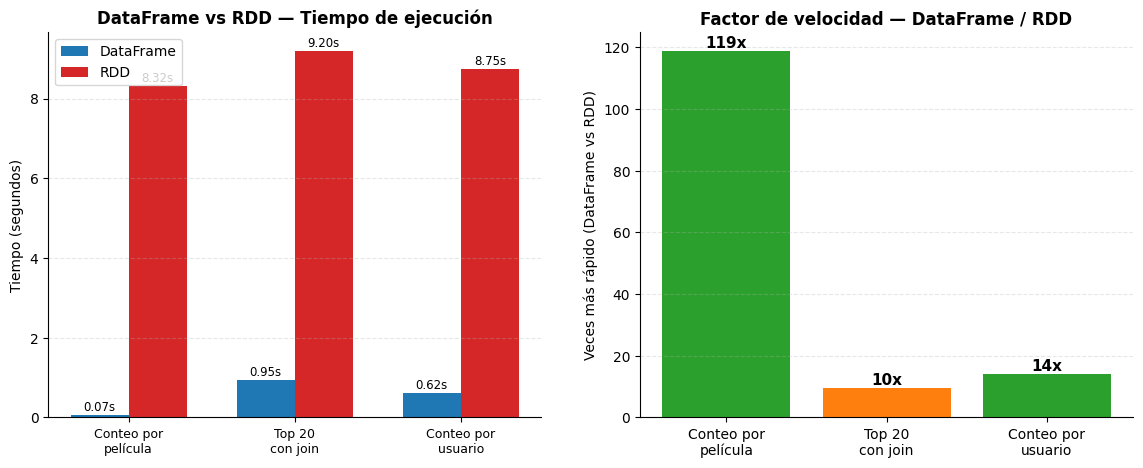

In [10]:
import matplotlib.pyplot as plt
import numpy as np

operaciones = ["Conteo por\npelícula", "Top 20\ncon join", "Conteo por\nusuario"]
tiempos_df  = [0.07, 0.95, 0.62]
tiempos_rdd = [8.32, 9.20, 8.75]

x = np.arange(len(operaciones))
ancho = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfica 1: barras agrupadas ---
bars1 = axes[0].bar(x - ancho/2, tiempos_df,  ancho, label="DataFrame", color="#1f77b4", edgecolor="none")
bars2 = axes[0].bar(x + ancho/2, tiempos_rdd, ancho, label="RDD",       color="#d62728", edgecolor="none")

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"{bar.get_height():.2f}s", ha="center", fontsize=8.5)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"{bar.get_height():.2f}s", ha="center", fontsize=8.5)

axes[0].set_xticks(x)
axes[0].set_xticklabels(operaciones, fontsize=9)
axes[0].set_ylabel("Tiempo (segundos)")
axes[0].set_title("DataFrame vs RDD — Tiempo de ejecución", fontweight="bold")
axes[0].legend()
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].grid(axis="y", alpha=0.3, linestyle="--")

# --- Gráfica 2: factor de velocidad ---
factores = [r/d for d, r in zip(tiempos_df, tiempos_rdd)]
colores  = ["#2ca02c" if f > 10 else "#ff7f0e" for f in factores]

bars3 = axes[1].bar(operaciones, factores, color=colores, edgecolor="none")
for bar, f in zip(bars3, factores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{f:.0f}x", ha="center", fontsize=11, fontweight="bold")

axes[1].set_ylabel("Veces más rápido (DataFrame vs RDD)")
axes[1].set_title("Factor de velocidad — DataFrame / RDD", fontweight="bold")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].grid(axis="y", alpha=0.3, linestyle="--")

> **DataFrame es consistentemente más rápido** en las 3 operaciones — el optimizador Catalyst de Spark genera un plan de ejecución eficiente automáticamente, algo que RDD no hace.

> **Conteo por película (119x)** — factor inflado por el caché de la primera ejecución. DataFrame aprovechó los datos ya en memoria; RDD los reprocesó desde cero.

> **Top 20 con join (10x)** — la operación más compleja (join + ordenamiento). DataFrame optimiza el join internamente; RDD requiere hacer el join manualmente paso a paso, sin optimización.

> **Conteo por usuario (14x)** — misma operación que Op1 pero sin caché. El factor real de DataFrame vs RDD en condiciones normales está en este rango (10x–14x).

> Para operaciones de agregación y join sobre datos masivos, DataFrame es siempre preferible. RDD tiene sentido solo cuando necesitas control fino sobre cada transformación, lo que este proyecto no requiere.

_Ellen te extraño :c_